In [14]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize_scalar, brentq
import mpmath as mp
from scipy import special
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import time
mp.mp.dps = 50

In [15]:
def iszero(a, eps=1e-6):
    if np.abs(a) < eps:
        return True
    return False

def inv_cdf(a, v):
    if iszero(a):
        return v
    return 1/a*(a/2-1+np.sqrt(2*a*v + (a/2-1)**2))

def inv_cdf_deriv(a, v):
    if iszero(a):
        return -1/8*(2*v-1)**2 + 1/8
    temp = np.sqrt(2*a*v + (a/2-1)**2)
    return 1/a**2 * (1. - temp) + 1/2/a / temp * (2*v + a/2 - 1)

def inv_cdf_numerical_deriv(a, v, eps=1e-3):
    # if iszero(a):
    #     return np.zeros_like(v)
    return (inv_cdf(a+eps, v) - inv_cdf(a-eps, v)) / 2 / eps

def get_m1_k_(a, k, n):
    if iszero(a):
        return k/(n+1)
    b = (0.5*a-1)**2
    return float(0.5 - 1/a + np.sqrt(b) / a * special.hyp2f1(-0.5, k, n+1, -2*a/b))

def get_m1_k(a, k, n):
    if iszero(a):
        return k/(n+1)
    b = (0.5*a-1)**2
    return float(0.5 - 1/a + np.sqrt(b) / a * mp.hyp2f1(-0.5, k, n+1, -2*a/b))

def get_m2(a):
    return (a+4)/12

def expected_wasserstein_loss_affine(a1, a2, n, m1_a1=None, m1_a2=None):
    if m1_a1 is None:
        m1_a1 = np.array([get_m1_k(a1, k+1, n) for k in range(n)])
    if m1_a2 is None:
        m1_a2 = np.array([get_m1_k(a2, k+1, n) for k in range(n)])
    dist = -2*np.mean(m1_a1*m1_a2) + get_m2(a1) + get_m2(a2)
    return dist

def expected_self_wasserstein_loss_affine(a, n, m1_a=None):
    if m1_a is None:
        m1_a = np.array([get_m1_k(a, k+1, n) for k in range(n)])
    return expected_wasserstein_loss_affine(a, a, n, m1_a1=m1_a, m1_a2=m1_a)

def expected_self_wasserstein_loss_affine_grad(a, n, eps=1e-3):
    distp = expected_self_wasserstein_loss_affine(a + eps, n)
    distm = expected_self_wasserstein_loss_affine(a - eps, n)
    return (distp - distm)/2/eps

In [16]:
def quantile_moment(a, k, n, eps=1e-6):
    if iszero(a, eps):
        return (2*k-1)/2/n**2
    b = (0.5*a-1)**2
    return (1/2-1/a)/n + 1/3/a**2*((2*a*k/n + b)**(3/2) - (2*a*(k-1)/n + b)**(3/2))

def expected_invcdf_block(a, k, n, eps=1e-6):
    if iszero(a, eps):
        return (2*k-1)/2/n**2
    ad = 2*a
    cd = a/2-1
    bd = cd**2
    return cd/a/n + 2/3/a/ad*((ad*k/n + bd)**(3/2) - (ad*(k-1)/n + bd)**(3/2))

# --------------------------------------------------------------------- #
#  Analytic derivatives                                                 #
# --------------------------------------------------------------------- #
def _g(a: float, k: np.ndarray, N: int) -> np.ndarray:
    """g_k(a) for an array of k."""
    return 2.0 * a * k / N + (0.5 * a - 1.0) ** 2

def _delta_phi(a: float, k: np.ndarray, N: int) -> np.ndarray:
    """Δφ_k(a) = φ_k − φ_{k−1} as vector over k."""
    gk   = _g(a, k,   N)
    gkm1 = _g(a, k-1, N)
    return gk**1.5 - gkm1**1.5
    
def _delta_phi_prime(a: float, k: np.ndarray, N: int) -> np.ndarray:
    """d/da Δφ_k(a)."""
    # derivative of g_k
    gk   = _g(a, k,   N)
    gkm1 = _g(a, k-1, N)
    gk_p   = 2.0 * k / N + 0.5 * a - 1.0
    gkm1_p = 2.0 * (k-1) / N + 0.5 * a - 1.0
    return 1.5 * (gk_p * np.sqrt(gk) - gkm1_p * np.sqrt(gkm1))

def quantile_moment_prime(a, k, N,
               dφ = None,
               dφ_p = None):
    if iszero(a, eps=1e-3):
        return (6*N*k - 3*N - 6*k*k + 6*k - 2) / 12 / N**3
    if dφ is None:
        dφ = _delta_phi(a, k, N)
    if dφ_p is None:
        dφ_p = _delta_phi_prime(a, k, N)

    return (1.0 / (N * a * a)
            - 2.0 * dφ / (3.0 * a**3)
            + dφ_p / (3.0 * a * a))

def expected_W_emp_emp_affine(x, a, m1s=None, r=1):
    N   = x.size
    if m1s is None:
        m1s = np.array([get_m1_k(a, i+1, r*N) for i in range(r*N)])
    return np.mean(-2.0 * np.repeat(x, r) * m1s) + np.sum(x*x)/N + get_m2(a)

def expected_W_emp_emp_affine_(x, a, m1s=None, r=1):
    N   = x.size
    if m1s is None:
        m1s = np.array([get_m1_k_(a, i+1, r*N) for i in range(r*N)])
    return np.mean(-2.0 * np.repeat(x, r) * m1s) + np.sum(x*x)/N + get_m2(a)

def expected_W_emp_emp_affine_grad(x, a, r=1, eps=1e-3):
    EWp = expected_W_emp_emp_affine(x, a+eps, r=r)
    EWm = expected_W_emp_emp_affine(x, a-eps, r=r)
    return (EWp - EWm) / 2 / eps

def W_emp_conti_affine(x, a, q1s=None):
    N   = x.size
    if q1s is None:
        q1s = np.array([quantile_moment(a, i+1, N) for i in range(N)])
    return np.sum(-2.0 * x * q1s) + get_m2(a) + np.sum(x*x)/N

def expected_W_emp_conti_affine(a1, a2, N, m1s=None, q1s=None):
    if m1s is None:
        m1s = np.array([get_m1_k(a1, i+1, N) for i in range(N)])
    if q1s is None:
        q1s = np.array([quantile_moment(a2, i+1, N) for i in range(N)])
    return np.sum(-2.0 * m1s * q1s) + get_m2(a2) + get_m2(a1)

def expected_W_emp_conti_affine_grad(a1, a2, N, m1s=None, eps=1e-3):
    if m1s is None:
        m1s = np.array([get_m1_k(a1, i+1, N) for i in range(N)])
    EWp = expected_W_emp_conti_affine(a1, a2+eps, N, m1s=m1s)
    EWm = expected_W_emp_conti_affine(a1, a2-eps, N, m1s=m1s)
    return (EWp - EWm) / 2 / eps

In [17]:
def numerical_sol_expected_loss(a1: float,
                         n:  int,
                        m1_a1 = None,
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500):
    """
    Find a2* that minimises   expected_wasserstein_loss_affine_emp_conti(a1, a2, n).

    Parameters
    ----------
    a1, n       : parameters forwarded to expected_wasserstein_loss_affine_emp_conti
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a2):
        return float(expected_wasserstein_loss_affine(a1, a2, n, m1_a1=m1_a1))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2, 2),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

In [18]:
def numerical_sol_expected_loss_debias(a1: float,
                         n:  int,
                        m1_a1 = None,
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500):
    """
    Find a2* that minimises   expected_wasserstein_loss_affine_emp_conti(a1, a2, n).

    Parameters
    ----------
    a1, n       : parameters forwarded to expected_wasserstein_loss_affine_emp_conti
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a2):
        m1_a2 = np.array([get_m1_k(a2, k+1, n) for k in range(n)])
        return float(expected_wasserstein_loss_affine(a1, a2, n, m1_a1=m1_a1, m1_a2=m1_a2) - 0.5*expected_wasserstein_loss_affine(a2, a2, n, m1_a1=m1_a2, m1_a2=m1_a2))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2, 2),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

In [19]:
def minimise_wasserstein_emp_conti(x, 
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500):
    """
    Find a* that minimises   W_emp_conti_affine(x, a).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a):
        return float(W_emp_conti_affine(x, a))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2.0 + eps, 2.0 - eps),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

def minimise_expected_W_emp_conti(a1, n, m1_a1=None, alpha=0,
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500):
    """
    Find a* that minimises   expected_W_emp_emp_affine(x, a, m1s=None, r=1).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a):
        return float(expected_W_emp_conti_affine(a1, a, n, m1s=m1_a1) - alpha*expected_self_wasserstein_loss_affine(a,n))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2.0 + eps, 2.0 - eps),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

def minimise_expected_W_emp_emp(x, r=1, alpha=0,
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500):
    """
    Find a* that minimises   expected_W_emp_emp_affine(x, a, m1s=None, r=1).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a):
        n = len(x)
        return float(expected_W_emp_emp_affine(x, a, r=r) - alpha*expected_self_wasserstein_loss_affine(a,n*r))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2.0 + eps, 2.0 - eps),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

In [20]:
def minimise_alpha_var(a1, N_set, m1_a1s=None,
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500):
    """
    Find a* that minimises   expected_W_emp_emp_affine(x, a, m1s=None, r=1).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a2):
        temp_alpha_set = np.empty(len(N_set))
        for j, N in enumerate(N_set):
            S_grad = expected_self_wasserstein_loss_affine_grad(a2, N)
            if m1_a1s is None:
                m1_a1 = None
            else:
                m1_a1 = m1_a1s[str(N)]
            J_SDa_grad = expected_W_emp_conti_affine_grad(a1, a2, N, m1s=m1_a1)
            temp_alpha = J_SDa_grad / S_grad
            temp_alpha_set[j] = temp_alpha
        return np.var(temp_alpha_set)
        
    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2.0 + eps, 2.0 - eps),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)



In [21]:
def emp_wass_1dim(x1, x2):
    x1 = np.sort(x1)
    x2 = np.sort(x2)
    N1 = len(x1)
    N2 = len(x2)
    r = N2//N1
    temp = 0
    for i in range(N1):
        temp += (x1[i] - x2[i*r:(i+1)*r])**2
    return (temp).sum()/N2



In [6]:
a_set = np.array([ 0.1, 0.5, 1., 1.5, 1.9, 1.99])
alpha_set = np.array([ 0.208, 0.209, 0.211, 0.225, 0.270, 0.288])

In [9]:
a_set2 = np.concatenate([-a_set, a_set])
alpha_set2 = np.concatenate([alpha_set, alpha_set])
indices = np.argsort(a_set2)
a_set2 = a_set2[indices]
alpha_set2 = alpha_set2[indices]

In [11]:
f = interp1d(a_set2, alpha_set2, kind='cubic')   # or 'quadratic', 'linear'
a_set_new = np.linspace(-1.99,1.99,100)
alpha_set_new = f(a_set_new)

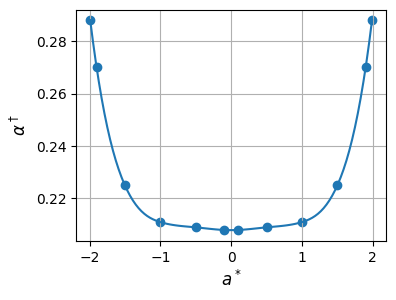

In [45]:
plt.figure(figsize=(4,3))
plt.scatter(a_set2, alpha_set2)
plt.plot(a_set_new, alpha_set_new)
plt.grid()
plt.xlabel(r'$a^*$', fontsize=12)
plt.ylabel(r'$\alpha^\dagger$', fontsize=12)
# plt.legend()
# plt.ylim(2.5,2.52)
# plt.savefig(f'./fig_alpha_affine_SD.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [26]:
N = 10
a1s = np.linspace(-1.99, 1.99, 201)
a2s = a1s
m1_a1s = [np.array([get_m1_k(a1, k+1, N) for k in range(N)]) for a1 in a1s]
m1_a2s = [np.array([get_m1_k(a2, k+1, N) for k in range(N)]) for a2 in a2s]
q1_a2s = [np.array([quantile_moment(a2, i+1, N) for i in range(N)]) for a2 in a2s]

In [23]:
expected_was = np.empty((len(a2s), len(a1s)))
for i, a1 in enumerate(a1s):
    for j, a2 in enumerate(a2s):
        expected_was[j,i] = expected_W_emp_conti_affine(a1, a2, N, m1s=m1_a1s[i], q1s=q1_a2s[j])

In [24]:
a1s_ = np.linspace(-1.99, 1.99, 51)
m1_a1s_ = [np.array([get_m1_k(a1, k+1, N) for k in range(N)]) for a1 in a1s_]
opt_a2s = np.empty(len(a1s_))
opt_vals = np.empty(len(a1s_))
for i, a1 in enumerate(a1s_):
    opt_a2s[i], opt_vals[i] = minimise_expected_W_emp_conti(a1, N, m1_a1=m1_a1s_[i])

In [31]:
np.max(expected_was)

0.12769259434621189

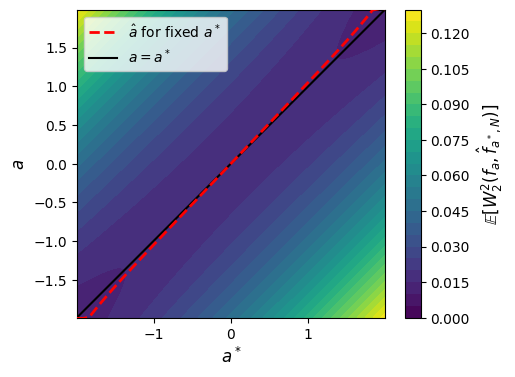

In [40]:
plt.figure(figsize=(5,4))
clev = np.linspace(0,0.13,27)
h = plt.contourf(a1s, a2s, expected_was, clev)
cbar = plt.colorbar()
cbar.set_label(r'$\mathbb{E}[W_2^2(f_a, \hat{f}_{a^*, N})]$', fontsize=12)
#plt.plot(w_list_np[:,0], w_list_np[:,1], c='orange', marker='o')

# cs = np.linspace(0.1, 2.0, 20)
# for c in cs:
#     temp_lambda2 = lambda1s/(2*lambda1s*c - 1)
#     plt.plot(1/lambda1s[temp_lambda2>lambda2s.min()], 1/temp_lambda2[temp_lambda2>lambda2s.min()], 'k--')
#plt.scatter(w_opt[0], w_opt[1], c='r', s=200, marker='*', zorder=10)
plt.axis('scaled')
plt.xlabel(r'$a^*$', fontsize=12)
plt.ylabel(r'$a$', fontsize=12)
plt.xlim([(a1s).min(), (a1s).max()])
plt.ylim([(a2s).min(), (a2s).max()])
plt.plot(a1s_, opt_a2s, 'r--', linewidth=2, label=r'$\hat{a}$ for fixed $a^*$', zorder=10)
plt.plot(a1s, a2s, 'k', label=r'$a = a^*$', zorder=1)
# plt.plot(a1s, a2s, 'y--')
plt.legend()
# plt.savefig(f'./fig_expected_loss_SD_affine.pdf', format='pdf', bbox_inches="tight", dpi=300)
plt.show()

In [27]:
expected_was_diag = np.empty((len(a2s), len(a1s)))
for j, a2 in enumerate(a2s):
    temp = expected_wasserstein_loss_affine(a2, a2, N, m1_a1=m1_a2s[j], m1_a2=m1_a2s[j])
    for i, a1 in enumerate(a1s):
        expected_was_diag[j,i] = temp

In [28]:
a1s_ = np.linspace(-1.99, 1.99, 51)
m1_a1s_ = [np.array([get_m1_k(a1, k+1, N) for k in range(N)]) for a1 in a1s_]
opt_a2s_debias = np.empty(len(a1s_))
opt_vals_debias = np.empty(len(a1s_))
for i, a1 in enumerate(a1s_):
    opt_a2s_debias[i], opt_vals_debias[i] = minimise_expected_W_emp_conti(a1, N, m1_a1=m1_a1s_[i], alpha=f(a1))

In [29]:
expected_was_debias = np.empty((len(a2s), len(a1s)))
for j, a2 in enumerate(a2s):
    for i, a1 in enumerate(a1s):
        expected_was_debias[j,i] = expected_was[j,i] - f(a1)*expected_was_diag[j,i]

In [33]:
np.max(expected_was_debias)

0.12141993269245475

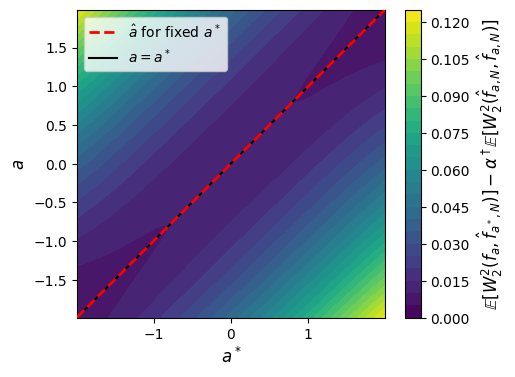

In [41]:
plt.figure(figsize=(5,4))
clev = np.linspace(0,0.125,26)
h = plt.contourf(a1s, a2s, expected_was_debias, clev)
cbar = plt.colorbar()
cbar.set_label(r'$\mathbb{E}[W_2^2(f_a, \hat{f}_{a^*, N})] - \alpha^\dagger\mathbb{E}[W_2^2(\hat{f}_{a, N}, \hat{f}_{a, N})]$', fontsize=12)
#plt.plot(w_list_np[:,0], w_list_np[:,1], c='orange', marker='o')

# cs = np.linspace(0.1, 2.0, 20)
# for c in cs:
#     temp_lambda2 = lambda1s/(2*lambda1s*c - 1)
#     plt.plot(1/lambda1s[temp_lambda2>lambda2s.min()], 1/temp_lambda2[temp_lambda2>lambda2s.min()], 'k--')
#plt.scatter(w_opt[0], w_opt[1], c='r', s=200, marker='*', zorder=10)
plt.axis('scaled')
plt.xlabel(r'$a^*$', fontsize=12)
plt.ylabel(r'$a$', fontsize=12)
plt.xlim([(a1s).min(), (a1s).max()])
plt.ylim([(a2s).min(), (a2s).max()])
plt.plot(a1s_, opt_a2s_debias, 'r--', linewidth=2, label=r'$\hat{a}$ for fixed $a^*$', zorder=10)
plt.plot(a1s, a2s, 'k', label=r'$a = a^*$', zorder=1)
# plt.plot(a1s, a2s, 'y--')
plt.legend()
# plt.savefig(f'./fig_expected_loss_SD_affine_modified.pdf', format='pdf', bbox_inches="tight", dpi=300)
plt.show()

In [44]:
opt_a2s_debias-a1s_

array([ 2.22192035e-03,  1.59723732e-03,  1.38582080e-03,  1.35176905e-03,
        1.36252698e-03,  1.35171414e-03,  1.28987955e-03,  1.17093685e-03,
        1.02347475e-03,  8.77107693e-04,  7.46658994e-04,  6.35031874e-04,
        5.36020793e-04,  4.39475837e-04,  3.46042005e-04,  2.61987425e-04,
        1.89762624e-04,  1.28908504e-04,  7.73015380e-05,  3.38964411e-05,
       -9.31235951e-07, -2.36152592e-05, -3.33197033e-05, -3.04904369e-05,
       -1.73052848e-05, -2.50032107e-05,  1.85955171e-05,  3.04767027e-05,
        3.33369901e-05,  2.36370094e-05,  8.92346899e-07, -3.38207056e-05,
       -7.73516592e-05, -1.28972606e-04, -1.89863511e-04, -2.62062783e-04,
       -3.46171873e-04, -4.39573684e-04, -5.36135668e-04, -6.35031581e-04,
       -7.46772754e-04, -8.77126644e-04, -1.02362855e-03, -1.17104040e-03,
       -1.28995438e-03, -1.35164206e-03, -1.36243551e-03, -1.35179503e-03,
       -1.38576733e-03, -1.59719146e-03, -2.22197047e-03])